In [1]:
from mpi4py import MPI
import numpy as np
import ufl
from dolfinx import mesh, fem
from dolfinx.fem.petsc import NonlinearProblem
from petsc4py import PETSc
from pathlib import Path
from dolfinx.io import XDMFFile
import csv
from scipy.interpolate import RegularGridInterpolator
import dolfinx.geometry as geometry
from scipy.interpolate import griddata
import wandb
import matplotlib.pyplot as plt

In [2]:
#dane SPE model 2, więcej info w spe_data.ipynb
REAL_NX, REAL_NY, REAL_NZ = 60, 220, 85
FT_TO_M = 0.3048

REAL_LX = REAL_NX * 20 * FT_TO_M # ok. 365.76 m
REAL_LY = REAL_NY * 10 * FT_TO_M # ok. 670.56 m

#skalowanie danych do zakresu [1, 10] 
def load_and_scale_kq(path):
    kq_layer = np.load(path) # Macierz (220, 60)
    
    log_kq = np.log10(kq_layer + 1e-6)
    
    max_scale = 100.0

    l_min, l_max = log_kq.min(), log_kq.max()
    k_scaled = (log_kq - l_min) / (l_max - l_min) * (max_scale - 1.0) + 1.0
    scale = (1.0, max_scale)
    
    return k_scaled, scale

kq_data_matrix, scale = load_and_scale_kq('spe_model2_layer50.npy')

#interpolator
x_coords = np.linspace(0, REAL_LX, REAL_NX)
y_coords = np.linspace(0, REAL_LY, REAL_NY)

#ciagła przestrzeń geometryczna do symulacji, wartości poza danymi przyjmują wartość 1.0 -> bounds_error=False, fill_value=1.0
interp_kq = RegularGridInterpolator((y_coords, x_coords), kq_data_matrix, 
                                    bounds_error=False, fill_value=1.0)


#tworzenie katalogów na wyniki
Path("results/fields").mkdir(parents=True, exist_ok=True)
Path("results/metrics").mkdir(parents=True, exist_ok=True)

#MPI.COMM_WORLD to komunikator dla wszystkich procesów
#tworze prostokąt o początku w 0,0 i końcu w wymiarach podanych w SPE

domain = mesh.create_rectangle(MPI.COMM_WORLD, 
                               [np.array([0, 0]), np.array([REAL_LX, REAL_LY])], 
                               [REAL_NX, REAL_NY])

#przestrzeń funkcyjna Lagrangea gdzie stopień wielomianu to 1
V = fem.functionspace(domain, ("Lagrange", 1))

Kq = fem.Function(V)
def kq_map(x):
    # Mapowanie punktów siatki MES na wartości z interpolatora
    pts = np.stack((x[1], x[0]), axis=-1) #zamieniony x z y, odwrotnie do tego jak zdefiniowaliśmy interpolator
    return interp_kq(pts) #interpolator oblicza wartość przepuszczalności w tych punktach



Kq.interpolate(kq_map) #wypełniamy siatkę wartościami przepuszczalności

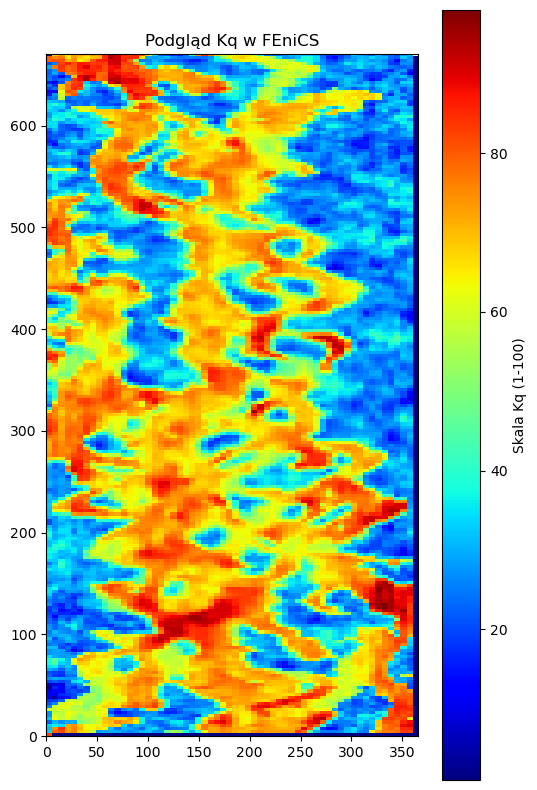

In [3]:
# --- SZYBKI TEST MAPY KQ ---
if MPI.COMM_WORLD.rank == 0:
    import matplotlib.pyplot as plt
    
    # 1. Wyciągamy współrzędne i wartości z obiektu FEniCS
    coords = V.tabulate_dof_coordinates()
    vals = Kq.x.array 

    # 2. Tworzymy siatkę do wizualizacji
    xi = np.linspace(0, REAL_LX, REAL_NX)
    yi = np.linspace(0, REAL_LY, REAL_NY)
    Xi, Yi = np.meshgrid(xi, yi)

    # 3. Interpolujemy chmurę punktów na macierz obrazka
    from scipy.interpolate import griddata
    Kq_check = griddata(coords[:, :2], vals, (Xi, Yi), method='linear')

    # 4. Wyświetlamy
    plt.figure(figsize=(6, 10))
    plt.imshow(Kq_check, extent=[0, REAL_LX, 0, REAL_LY], cmap='jet', origin='lower')
    plt.colorbar(label="Skala Kq (1-100)")
    plt.title("Podgląd Kq w FEniCS")
    plt.show() # To otworzy okno z obrazkiem
    # plt.savefig("test_kq.png") # Lub odkomentuj, żeby zapisać do pliku
# ---------------------------